# Training a simple CNN model in `keras` (>3.0) for Tornado Detection

This notebook steps through how to train a simple CNN model using a subset of TorNet.

This will not produce a model with any skill, but simply provides a working end-to-end example of how to set up a data loader, build, and fit a model


In [27]:
import os
os.environ['KERAS_BACKEND']='tensorflow' # set to 'tensorflow', 'torch' or 'jax' (installs required)

In [28]:
import sys
# Uncomment if tornet isn't installed in your environment or in your path already
sys.path.append('../')

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras

from tornet.data.tf.loader import create_tf_dataset 
from tornet.data.constants import ALL_VARIABLES

In [29]:
# keras accepts most data loaders (tensorflow, torch).
# A pure keras data loader, with necessary preprocessing steps for the cnn baseline, is provided
from tornet.data.keras.loader import KerasDataLoader
data_root = "/Users/evanshabsove/Documents/georgian/summer_2025/AIDI-1004/assignment-2/tornet/tornet_data"
ds = KerasDataLoader(data_root=data_root,
                     data_type='train',
                     years=[2013],
                     batch_size = 128,
                     workers = 4,
                     use_multiprocessing = True)


In [30]:
# Create a simple CNN model
# This normalizes data, concatenates along channel, and applies a Conv2D
from tornet.data.constants import CHANNEL_MIN_MAX
from tornet.models.keras.layers import FillNaNs

input_vars = ALL_VARIABLES # which variables to use

# TF convention is B,L,W,H
inputs = {v:keras.Input(shape=(120,240,2),name=v) for v in input_vars}

# Normalize inputs
norm_layers = []
for v in input_vars:
    min_max = np.array(CHANNEL_MIN_MAX[v]) # [2,]

    # choose mean,var to get approximate [-1,1] scaling
    var=((min_max[1]-min_max[0])/2)**2 # scalar
    var=np.array(2*[var,])    # [n_sweeps,]
    offset=(min_max[0]+min_max[1])/2    # scalar
    offset=np.array(2*[offset,]) # [n_sweeps,]
    
    norm_layers.append(
        keras.layers.Normalization(mean=offset, variance=var,
                                   name='Normalized_%s' % v)
    )

# Concatenate normed inputs along channel dimension
x=keras.layers.Concatenate(axis=-1,name='Concatenate1')(
        [l(inputs[v]) for l,v in zip(norm_layers,input_vars)]
        )

# Replace background (nan) with -3
x = FillNaNs(fill_val=-3,name='ReplaceNan')(x)

# Processing
x = keras.layers.Conv2D(32,3,padding='same',activation='relu')(x)
# add more..
x = keras.layers.Conv2D(1,1,padding='same',activation='relu',name='TornadoLikelihood')(x)
y = keras.layers.GlobalMaxPool2D(name='GlobalMaxPool')(x)

model = keras.Model(inputs=inputs,outputs=y,name='TornadoDetector')

model.summary()

Model: "TornadoDetector"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ DBZ (InputLayer)    │ (None, 120, 240,  │          0 │ -                 │
│                     │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ VEL (InputLayer)    │ (None, 120, 240,  │          0 │ -                 │
│                     │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ KDP (InputLayer)    │ (None, 120, 240,  │          0 │ -                 │
│                     │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ RHOHV (InputLayer)  │ (None, 120, 240,  │          0 │ -                 │
│                     │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ZDR (InputLayer)    │ (None, 120, 240,  │          0 │ -                 │
│                     │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ WIDTH (InputLayer)  │ (None, 120, 240,  │          0 │ -                 │
│                     │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Normalized_DBZ      │ (None, 120, 240,  │          0 │ DBZ[0][0]         │
│ (Normalization)     │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Normalized_VEL      │ (None, 120, 240,  │          0 │ VEL[0][0]         │
│ (Normalization)     │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Normalized_KDP      │ (None, 120, 240,  │          0 │ KDP[0][0]         │
│ (Normalization)     │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Normalized_RHOHV    │ (None, 120, 240,  │          0 │ RHOHV[0][0]       │
│ (Normalization)     │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Normalized_ZDR      │ (None, 120, 240,  │          0 │ ZDR[0][0]         │
│ (Normalization)     │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Normalized_WIDTH    │ (None, 120, 240,  │          0 │ WIDTH[0][0]       │
│ (Normalization)     │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Concatenate1        │ (None, 120, 240,  │          0 │ Normalized_DBZ[0… │
│ (Concatenate)       │ 12)               │            │ Normalized_VEL[0… │
│                     │                   │            │ Normalized_KDP[0… │
│                     │                   │            │ Normalized_RHOHV… │
│                     │                   │            │ Normalized_ZDR[0… │
│                     │                   │            │ Normalized_WIDTH… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ isnan_3 (Isnan)     │ (None, 120, 240,  │          0 │ Concatenate1[0][… │
│                     │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ where_3 (Where)     │ (None, 120, 240,  │          0 │ isnan_3[0][0],    │
│                     │ 12)               │            │ Concatenate1[0][… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# Compile
import tornet.metrics.keras.metrics as km

opt  = keras.optimizers.Adam(learning_rate=1e-3)
loss=keras.losses.BinaryCrossentropy(from_logits=True)
metrics = [
    keras.metrics.AUC(from_logits=True, name='AUC'),
    km.BinaryAccuracy(from_logits=True, name='BinaryAccuracy'),
    keras.metrics.Precision(name='Precision'),
    keras.metrics.Recall(name='Recall')
]
model.compile(loss=loss, optimizer=opt, metrics=metrics)

In [32]:
# Train
# steps_per_epoch=10 for demo purposes
history = model.fit(ds,epochs=25)

Epoch 1/25


/opt/anaconda3/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'DBZ': 'DBZ', 'VEL': 'VEL', 'KDP': 'KDP', 'RHOHV': 'RHOHV', 'ZDR': 'ZDR', 'WIDTH': 'WIDTH'}
Received: inputs={'DBZ': 'Tensor(shape=(None, 120, 240, 2))', 'VEL': 'Tensor(shape=(None, 120, 240, 2))', 'KDP': 'Tensor(shape=(None, 120, 240, 2))', 'RHOHV': 'Tensor(shape=(None, 120, 240, 2))', 'ZDR': 'Tensor(shape=(None, 120, 240, 2))', 'WIDTH': 'Tensor(shape=(None, 120, 240, 2))', 'range_folded_mask': 'Tensor(shape=(None, 120, 240, 2))', 'label': 'Tensor(shape=(None,))', 'category': 'Tensor(shape=(None,))', 'event_id': 'Tensor(shape=(None,))', 'ef_number': 'Tensor(shape=(None,))', 'az_lower': 'Tensor(shape=(None,))', 'az_upper': 'Tensor(shape=(None,))', 'rng_lower': 'Tensor(shape=(None,))', 'rng_upper': 'Tensor(shape=(None,))', 'time': 'Tensor(shape=(None,))', 'tornado_start_time': 'Tensor(shape=(None,))', 'tornado_end_time': 

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - AUC: 0.3310 - BinaryAccuracy: 0.0700 - Precision: 0.0714 - Recall: 1.0000 - loss: 1.5850
Epoch 2/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - AUC: 0.3656 - BinaryAccuracy: 0.0700 - Precision: 0.0722 - Recall: 1.0000 - loss: 1.2718
Epoch 3/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - AUC: 0.4055 - BinaryAccuracy: 0.0800 - Precision: 0.0563 - Recall: 0.5714 - loss: 1.0377
Epoch 4/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - AUC: 0.4270 - BinaryAccuracy: 0.1100 - Precision: 0.0400 - Recall: 0.1429 - loss: 0.8921
Epoch 5/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - AUC: 0.5253 - BinaryAccuracy: 0.2400 - Precision: 0.0833 - Recall: 0.1429 - loss: 0.8038
Epoch 6/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - AUC: 0.6137 - BinaryAccuracy: 0.4300 - Precision: 0.0000e+00 - Recall: 0.0000e+00 - loss: 0.7564
Epoch 7/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - AUC: 0.6736 - BinaryAccuracy: 0.5300 - Precision: 0.0000e+00 - Recall: 0.0000e+00 - loss: 0.7317
Epoch 8/25
1/1 

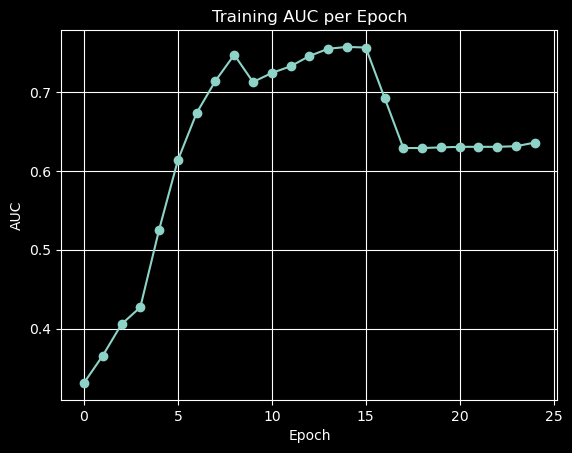

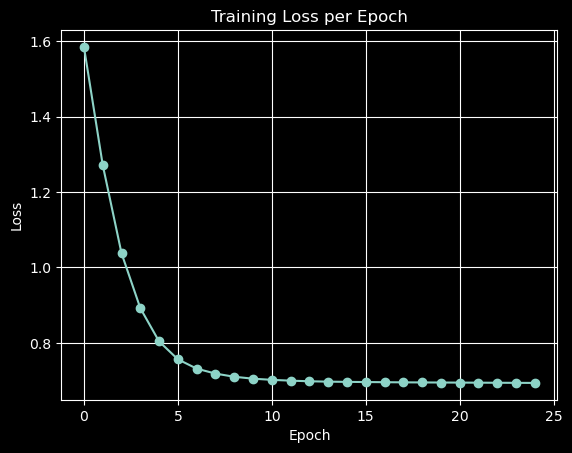

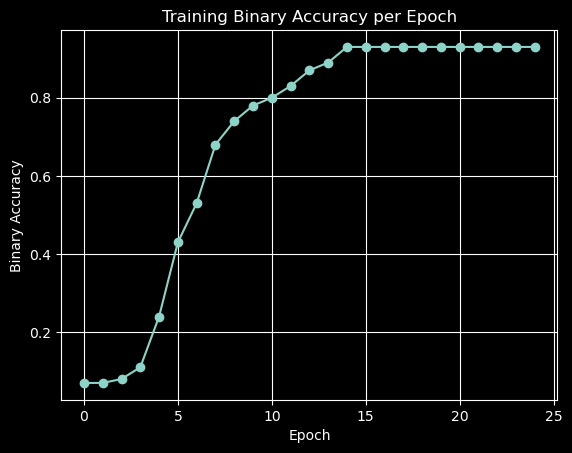

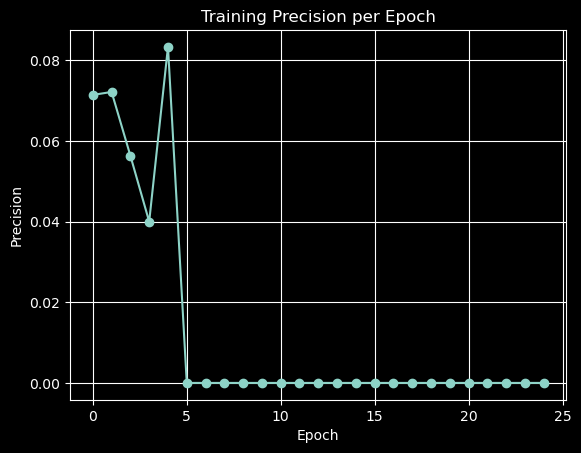

In [33]:
# Graphing AUC for each epoch
import matplotlib.pyplot as plt

# Plot AUC for each epoch
plt.plot(history.history['AUC'], marker='o')
plt.title('Training AUC per Epoch')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.grid(True)
plt.show()


plt.plot(history.history['loss'], marker='o')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

plt.plot(history.history['BinaryAccuracy'], marker='o')
plt.title('Training Binary Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Binary Accuracy')
plt.grid(True)
plt.show()

plt.plot(history.history['Precision'], marker='o')
plt.title('Training Precision per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.grid(True)
plt.show()

In [34]:
# Build a test set
ds_test = KerasDataLoader(data_root=data_root,
                         data_type='test',
                         years=[2013],
                         batch_size = 128,
                         workers = 4,
                         use_multiprocessing = True)


In [35]:
# Evaluate
import tornet.metrics.keras.metrics as km
metrics = [keras.metrics.AUC(from_logits=True,name='AUC'),
           km.BinaryAccuracy(from_logits=True,name='BinaryAccuracy'),
           keras.metrics.Precision(name='Precision'),
           keras.metrics.Recall(name='Recall')
           ]
model.compile(loss=loss,metrics=metrics)

# steps=10 for demo purposes
model.evaluate(ds_test,steps=10)


/opt/anaconda3/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'DBZ': 'DBZ', 'VEL': 'VEL', 'KDP': 'KDP', 'RHOHV': 'RHOHV', 'ZDR': 'ZDR', 'WIDTH': 'WIDTH'}
Received: inputs={'DBZ': 'Tensor(shape=(None, 120, 240, 2))', 'VEL': 'Tensor(shape=(None, 120, 240, 2))', 'KDP': 'Tensor(shape=(None, 120, 240, 2))', 'RHOHV': 'Tensor(shape=(None, 120, 240, 2))', 'ZDR': 'Tensor(shape=(None, 120, 240, 2))', 'WIDTH': 'Tensor(shape=(None, 120, 240, 2))', 'range_folded_mask': 'Tensor(shape=(None, 120, 240, 2))', 'label': 'Tensor(shape=(None,))', 'category': 'Tensor(shape=(None,))', 'event_id': 'Tensor(shape=(None,))', 'ef_number': 'Tensor(shape=(None,))', 'az_lower': 'Tensor(shape=(None,))', 'az_upper': 'Tensor(shape=(None,))', 'rng_lower': 'Tensor(shape=(None,))', 'rng_upper': 'Tensor(shape=(None,))', 'time': 'Tensor(shape=(None,))', 'tornado_start_time': 'Tensor(shape=(None,))', 'tornado_end_time': 

10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - AUC: 0.6006 - BinaryAccuracy: 0.7900 - Precision: 0.0000e+00 - Recall: 0.0000e+00 - loss: 0.7026


/opt/anaconda3/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


[0.7026399374008179, 0.6006128787994385, 0.7900000214576721, 0.0, 0.0]